# Telecom Customer Churn Analysis

## 02: Univariate Analysis

### Objective
This notebook explores the individual characteristics and distributions of variables in the cleaned Telecom Customer Churn dataset.

The analysis focuses on:
- Understanding the demographic and geographic characteristics of the customer base
- Examining customer tenure and referral behavior
- Evaluating adoption across available services
- Analyzing customer billing and financial characteristics
- Examining the overall distribution of customer status and churn-related attributes

This establishes a baseline understanding of the customer base before investigating relationships between variables and customer churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load output from first notebook
churn_df = pd.read_parquet('../data/processed/telecom_customer_churn_clean.parquet')

In [112]:
colors = {
    'blue': '#1E3A8A',
    'berry': '#D1345B',
    'teal': "#14B8A6",
    'darkblue': '#263252',
    'red': '#ff3f34'

    
}

## Customer Profile

This section examines the demographic and geographic characteristics of the customer base, along with customer tenure and referral behavior.

### Gender
- What proportion of the customer base does each gender represent?
- Is the customer base balanced across genders?

In [120]:
churn_df['Gender'].value_counts(normalize=True) * 100

Gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

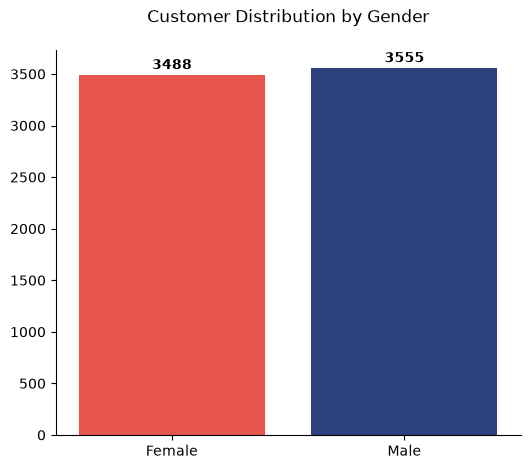

In [118]:
plt.figure(figsize=(6, 5))

ax = sns.countplot(
    churn_df,
    x='Gender',
    hue='Gender',
    dodge=False,
    palette=[colors['red'], colors['blue']]

)

for container in ax.containers:
    ax.bar_label(
        container,
        fontweight='bold',
        padding=2
    )

plt.title('Customer Distribution by Gender', pad=20)
plt.ylabel('')
plt.xlabel('')
sns.despine()
plt.show()


### Age
- What are the average and median ages of customers? 
- How are customer ages destributed?
- What is the age range of the customer base, any potential outliers?

In [121]:
churn_df['Age'].describe()

count       7043.0
mean     46.509726
std      16.750352
min           19.0
25%           32.0
50%           46.0
75%           60.0
max           80.0
Name: Age, dtype: Float64

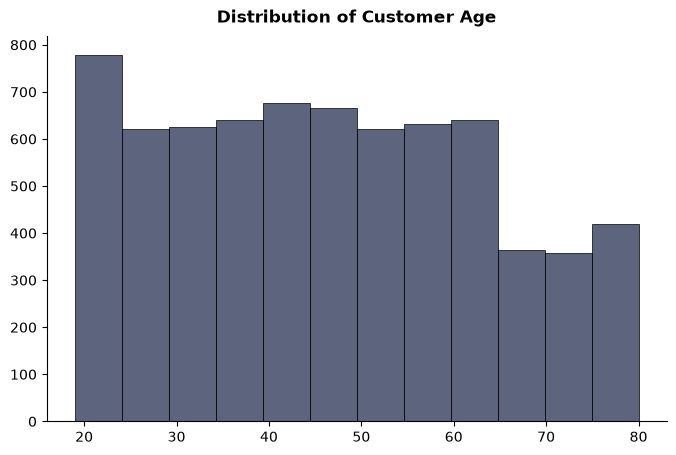

In [165]:
plt.figure(figsize=(8, 5))

sns.histplot(
    churn_df,
    x='Age',
    binwidth=5,
    color=colors['darkblue'],
    linewidth=0.5
)

plt.title('Distribution of Customer Age', pad=10, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
sns.despine()
plt.show()

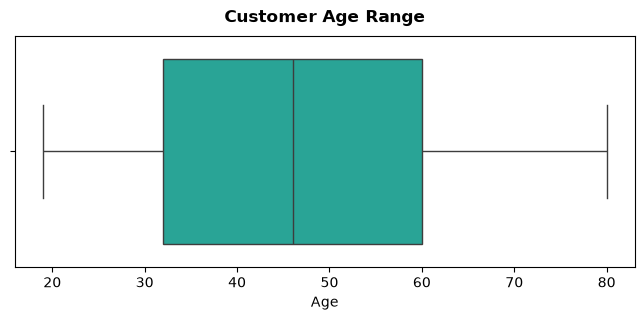

In [163]:
plt.figure(figsize=(8, 3))

sns.boxplot(
    churn_df,
    x='Age',
    color=colors['teal']
)


plt.title('Customer Age Range', pad=10, fontweight='bold')
plt.show()

#### Marital Status

- What proportion of customers are married versus unmarried?
- Is the customer base balanced by marital status?

In [166]:
churn_df['Married'].value_counts(normalize=True) * 100

Married
False    51.69672
True     48.30328
Name: proportion, dtype: Float64

#### Number of Dependents

- What proportion of customers have no dependents?
- How are customers distributed by number of dependents?
- What is the maximum number of dependents reported?

In [168]:
churn_df['Number of Dependents'].describe()

count      7043.0
mean     0.468692
std      0.962802
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           9.0
Name: Number of Dependents, dtype: Float64

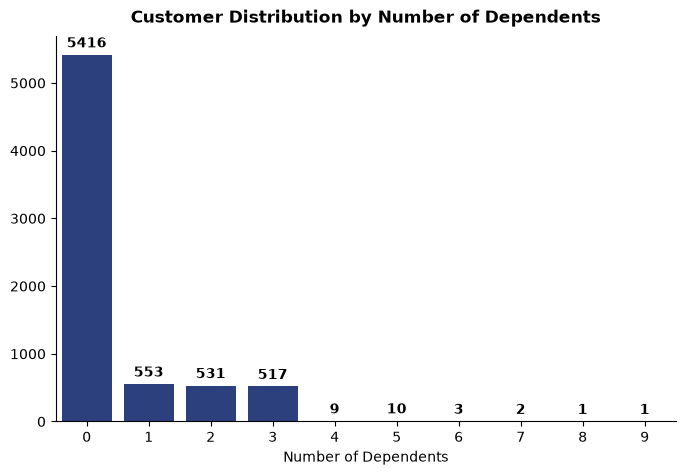

In [190]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    churn_df,
    x='Number of Dependents',
    color=colors['blue']
)

ax.bar_label(
    ax.containers[0],
    padding=3,
    fontweight='bold'
)

plt.title('Customer Distribution by Number of Dependents', fontweight='bold', pad=10)
plt.ylabel('')
plt.xlabel('Number of Dependents')
sns.despine()
plt.show()

In [191]:
churn_df['Number of Dependents'].value_counts(normalize=True) * 100

Number of Dependents
0    76.899049
1     7.851768
2     7.539401
3     7.340622
5     0.141985
4     0.127786
6     0.042595
7     0.028397
9     0.014198
8     0.014198
Name: proportion, dtype: Float64

### Demographic Observations

**Gender**
- The customer base is nearly evenly distributed by gender, with male customers accounting for approximately 50.5% and female customers accounting for 49.5%, indicating no notable gender imbalance.

**Age**
- Customer ages range from 19 to 80 years old, with an average age of approximately 46 years.
- The age distribution is relatively even across much of the age range, with a higher concentration among younger customers aged 19–25 and a gradual decline among customers aged 65–80. 
- The middle 50% of customers are between 32 and 60 years old.
- There are no apparent age outliers or implausible values in the records on age.

**Marital Status**
- Approximately 51.7% of customers are unmarried, while 48.3% are married, indicating that the customer base is relatively balanced in terms of marital status.

**Number of Dependents**
- Approximately 77% of customers report having no dependents.
- Customers with 1-3 dependents each account for approximately 7.5% of the customer base, while customers with 4 or more dependents collectively account for only about 1.5%.

### City
- How many unique cities are represented in the customer base?
- What are the top 10 cities with the most customers?
- What percentage of the customer base is concentrated in the top 10 cities?
- Is the customer base geographically concentrated or dispersed across cities?

In [193]:
churn_df['City'].nunique()

1106

Text(0.5, 0, '')

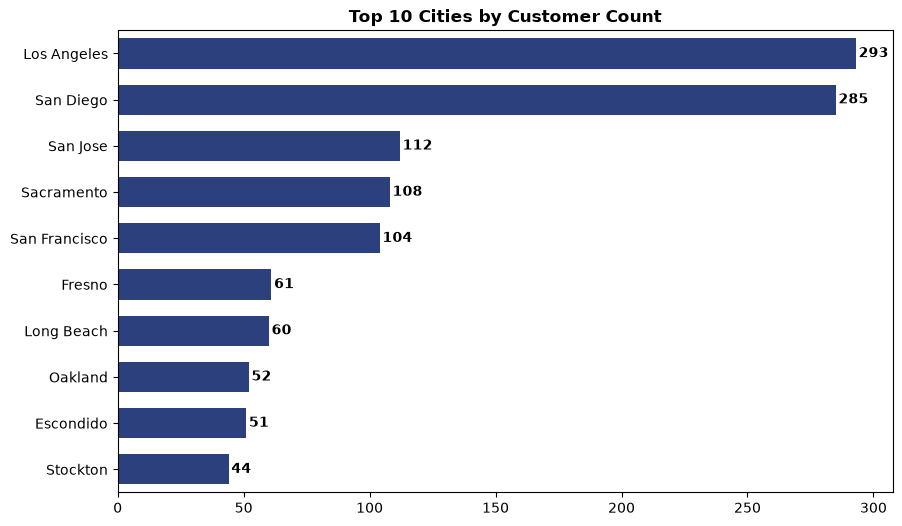

In [230]:
top10_cities = churn_df['City'].value_counts().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top10_cities.values,
    y=top10_cities.index,
    color=colors['blue'],
    width=0.65
)

ax.bar_label(
    ax.containers[0],
    padding=2,
    fontweight='bold'
)

plt.title('Top 10 Cities by Customer Count', fontweight='bold')
plt.ylabel('')
plt.xlabel('')

In [200]:
(top10_cities / len(churn_df)).sum() * 100

np.float64(16.612239102655117)

### Zip Code

- How many unique ZIP codes are represented in the customer base?
- How many customers are in the most frequently represented ZIP code?

In [231]:
churn_df['Zip Code'].nunique()

1626

In [234]:
churn_df['Zip Code'].value_counts()

Zip Code
92028    43
92027    38
92122    36
92117    34
92126    32
         ..
95431     2
92250     2
96150     2
91934     2
93711     1
Name: count, Length: 1626, dtype: int64[pyarrow]

### Geographic Observations

**City**
- The customer base spans 1,106 unique cities, indicating broad geographic coverage.
- Los Angeles and San Diego have the highest customer counts with 293 and 285 customers, respectively. 
- Despite this, the top 10 cities account for only 16.6% of the entire customer base, suggesting that customers are geographically dispersed rather than concentrated in a small number of cities.

**Zip Code**
- The ZIP code distribution further supports the geographic dispersion observed across cities. Customers are spread across 1,626 unique ZIP codes, with the most represented ZIP code containing only 43 customers.

### Number of Referrals
- What is the average number of referrals per customer?
- What proportion of customer have made no referrals?
- What is the maximum number of referrals made by a customer?
- How are customers distributed by number of referrals

In [235]:
churn_df['Number of Referrals'].describe()

count      7043.0
mean     1.951867
std      3.001199
min           0.0
25%           0.0
50%           0.0
75%           3.0
max          11.0
Name: Number of Referrals, dtype: Float64

In [238]:
churn_df['Number of Referrals'].value_counts(normalize=True).sort_index() * 100

Number of Referrals
0     54.252449
1     15.419566
2      3.350845
3      3.620616
4      3.350845
5      3.748403
6      3.137867
7      3.521227
8      3.024279
9      3.379242
10     3.166264
11     0.028397
Name: proportion, dtype: Float64

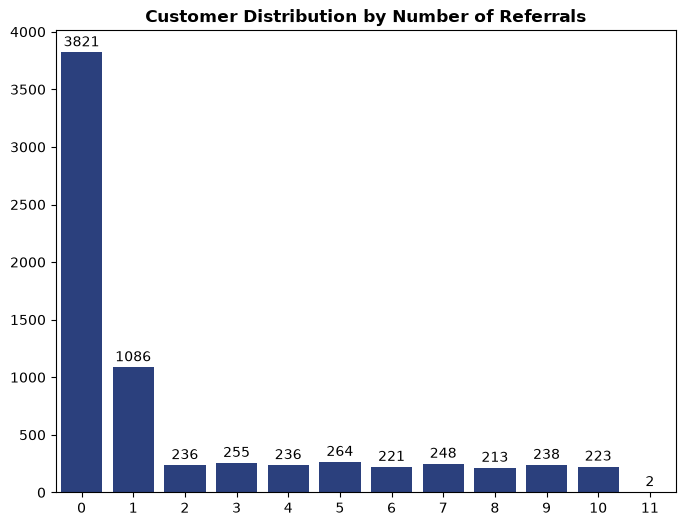

In [247]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    churn_df,
    x='Number of Referrals',
    color=colors['blue']
)

ax.bar_label(ax.containers[0],
             padding=2,
             fontweight='light')

plt.title('Customer Distribution by Number of Referrals', fontweight='bold')
plt.ylabel('')
plt.xlabel('')
plt.show()

### Tenure in Months
- What is the average and median custoemr tenure?
- What is the range of customer tenure?
- How are customers distributed across different tenure lengths?
- Are there any unusually low or high tenure values?

In [248]:
churn_df['Tenure in Months'].describe()

count       7043.0
mean     32.386767
std      24.542061
min            1.0
25%            9.0
50%           29.0
75%           55.0
max           72.0
Name: Tenure in Months, dtype: Float64

Text(0, 0.5, '')

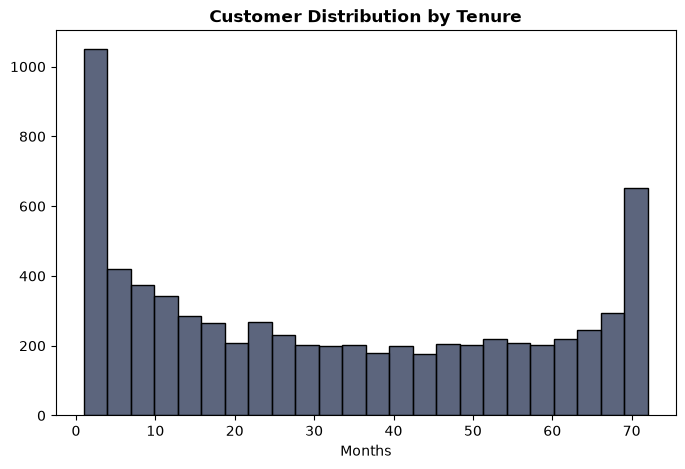

In [255]:
plt.figure(figsize=(8, 5))

sns.histplot(
    churn_df,
    x='Tenure in Months',
    binwidth=3,
    color=colors['darkblue']
)

plt.title('Customer Distribution by Tenure', fontweight='bold')
plt.xlabel('Months')
plt.ylabel('')

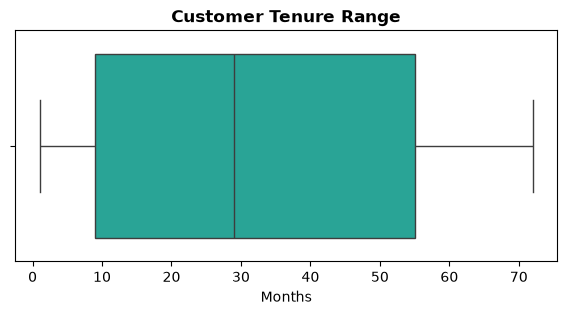

In [267]:
plt.figure(figsize=(7, 3))

sns.boxplot(
    churn_df,
    x='Tenure in Months',
    color=colors['teal']
)

plt.title('Customer Tenure Range', fontweight='bold')
plt.xlabel('Months')
plt.show()

### Customer Relationship Observations

**Number of Referrals**
- Customer referrals are heavily concentrated at the lower end, with approximately 54% of customers having made no referrals and around 15% having made only one.
- Customers with 2–10 referrals are less common and relatively evenly distributed, while the maximum number of referrals recorded is 11.

**Tenure in Months**
- Customer tenure ranges from 1 to 72 months, with an average tenure of approximately 32 months and a median of 29 months.
- The tenure distribution shows higher concentrations among both newer customers and long-tenured customers, particularly near the lower and upper ends of the range, rather than being concentrated around the middle.
- No unusually low or high tenure values are apparent from the distribution.

## Service Adoption

This section examines customer adoption across the company's phone, internet, and related service offerings.

In [268]:
service_columns = [
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music',
    'Unlimited Data'
]

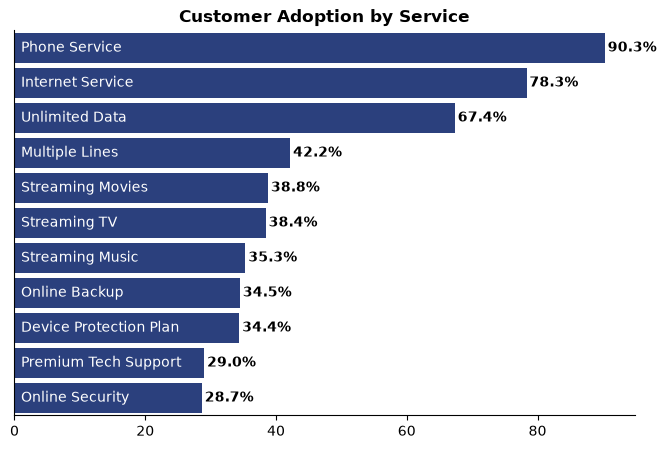

In [ ]:
service_adoption = churn_df[service_columns].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=service_adoption.values,
    y=service_adoption.index,
    color=colors['blue'],
    width=0.85
)

ax.bar_label(ax.containers[0], 
             padding=2, 
             fontweight='bold',
             fmt='%.1f%%')

ax.set_yticks([])

for bar, label in zip(ax.patches, service_adoption.index):
    ax.text(
        1,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center',
        ha='left',
        color='white',
        fontweight='light'
    )
    
plt.title('Customer Adoption by Service', fontweight='bold')
plt.ylabel('')
plt.xlabel('')
sns.despine()
plt.show()

## Customer Offers and Contracts

This section examines customers' accepted marketing offers and contract arrangements.

## Billing and Financial Profile

This section examines customer charges, revenue, refunds, and payment characteristics to understand the financial profile of the customer base.

## Customer Status and Churn Profile

This section examines the overall distribution of customer statuses and the documented categories and reasons associated with customer churn.